In [ ]:
import torch
from pyro.infer import Predictive

import matplotlib.pyplot as plt
from multistate import MultistateModel

In [12]:
illness_death = MultistateModel(
    states=["healthy", "ill", "dead"],
    transitions=[(0, 1), (0, 2), (1, 2)],
    absorbing=[2]
)
true_rates = torch.tensor([0.3, 0.05, 0.5])
exp_data = illness_death.simulate(hazard="exponential", rates=true_rates)

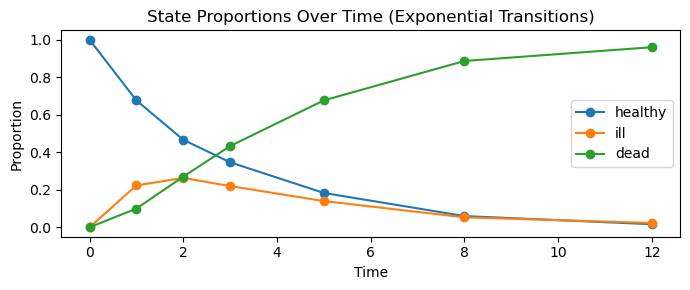

In [16]:
# Proportion of individuals in each state at each time point
state_counts = exp_data.groupby("obs_time")["state"].value_counts().unstack(fill_value=0)
state_counts.columns = illness_death.states
state_proportions = state_counts.div(state_counts.sum(axis=1), axis=0)
state_proportions.plot(marker="o", figsize=(7, 3))
plt.xlabel("Time")
plt.ylabel("Proportion")
plt.title("State Proportions Over Time (Exponential Transitions)")
plt.tight_layout()
plt.show()

Step 0 : loss = 1832.1772
Step 500 : loss = 882.2577
Step 1000 : loss = 881.6264
Step 1500 : loss = 881.0418
Step 2000 : loss = 881.9999
Step 2500 : loss = 881.2103


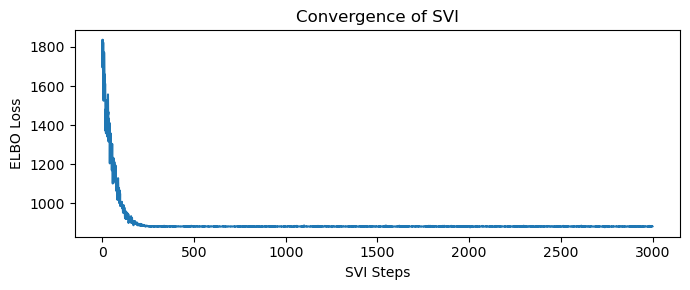

In [18]:
model_exp, guide_exp, loss_exp = illness_death.fit(exp_data, hazard="exponential", num_steps=3000)

plt.figure(figsize=(7, 3))
plt.plot(loss_exp)
plt.xlabel("SVI Steps")
plt.ylabel("ELBO Loss")
plt.title("Convergence of SVI")
plt.tight_layout()
plt.show()

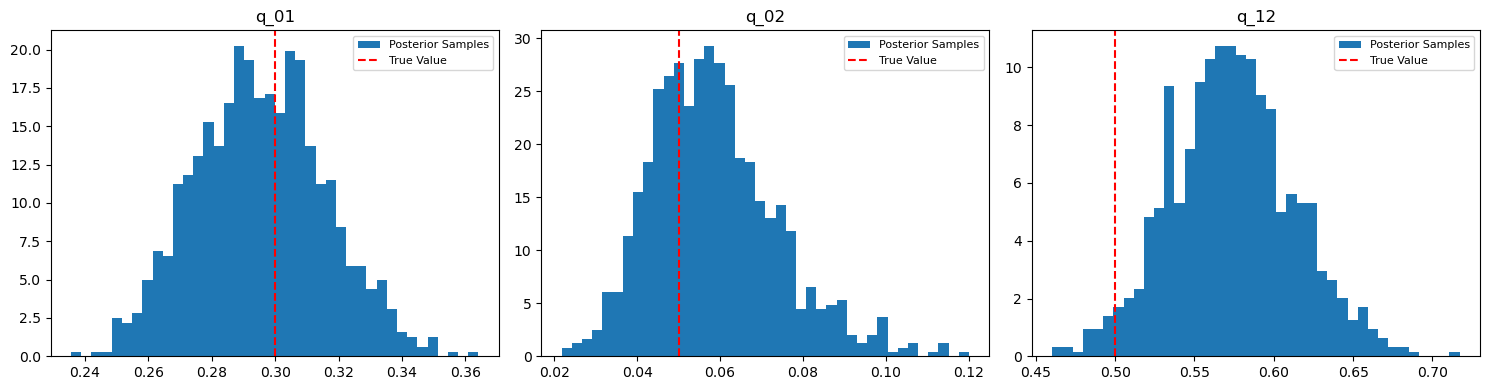

In [20]:
trans_labels = [f"q_{i}{j}" for i, j in illness_death.transitions]
pred = Predictive(model_exp, guide=guide_exp, num_samples=1000, return_sites=trans_labels)

with torch.no_grad():
    posterior_samples = pred()

fig, axes = plt.subplots(1, len(trans_labels), figsize=(15, 4))
for ax, label, true_val in zip(axes, trans_labels, true_rates):
    samples = posterior_samples[label].numpy()
    ax.hist(samples, bins=40, density=True, label="Posterior Samples")
    ax.axvline(true_val.item(), color="red", linestyle="--", label="True Value")
    ax.set_title(label)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()